# 003 — AFTER v2.4 Results Analysis

**Inputs:** `Results_v2_4/` outputs from `AFTER_detector.py`

**Four scientific questions:**
1. What does AFTER detect and with what confidence?
2. How well does AFTER recover known FD events (FEID 2019)?
3. Does the detected population have a real heliospheric signature?
4. What does AFTER miss and why?

**Figures:** only where a visual is strictly more informative than text or a table.

## 0. Imports & paths

In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from IPython.display import display

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE        = Path("Results_v2_4")
OUT         = BASE / "Analysis"
OUT.mkdir(parents=True, exist_ok=True)

ALLDATA_1H  = Path("alldata_integrated_1h.parquet")
ALLDATA_2M  = Path("alldata_integrated_2min.parquet")
PANELS_DIR  = BASE / "station_panels"

# Matplotlib style — publication ready
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.labelsize":   12,
    "axes.titlesize":   12,
    "legend.fontsize":  9,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

COLORS = {
    "all":         "#4d4d4d",
    "core_main":   "#2166ac",
    "core_cons":   "#4dac26",
    "exploratory": "#d7191c",
    "feid_all":    "#000000",
    "feid_1pct":   "#fc8d59",
    "confirmed":   "#1a9641",
    "unconfirmed": "#d7191c",
    "cond_A":      "#2166ac",
    "cond_B":      "#f4a582",
    "cond_C":      "#92c5de",
    "tp":          "#2166ac",
    "fn":          "#d7191c",
}
ATH = 2.0   # trigger threshold

SAVE_FIGS = True
def savefig(name):
    if SAVE_FIGS:
        plt.savefig(OUT / name, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


## 1. Load data

In [2]:
# ── Catalogue ─────────────────────────────────────────────────────────────────
cat = pd.read_csv(BASE / "AFTER_catalog_detector.csv")
cat["repr_time"] = pd.to_datetime(cat["repr_time"])
if cat["repr_time"].dt.tz is not None:
    cat["repr_time"] = cat["repr_time"].dt.tz_convert(None)
cat["year"] = cat["repr_time"].dt.year

core  = cat[cat["n_supported_stations"] >= 2].copy()
expl  = cat[cat["n_supported_stations"] <  2].copy()
core_cons = cat[(cat["n_supported_stations"] >= 2) &
                (cat["n_support_only_stations"] >= 1)].copy()

# fd_like columns
has_fdlike = "fd_like_confirmed" in cat.columns
if has_fdlike:
    core_confirmed   = core[core["fd_like_confirmed"] == True].copy()
    core_unconfirmed = core[core["fd_like_confirmed"] == False].copy()

# ── FEID ──────────────────────────────────────────────────────────────────────
feid = pd.read_parquet("feid_clean.parquet")
feid.index = pd.to_datetime(feid.index)
feid["t_izmiran"] = feid.index
if feid["t_izmiran"].dt.tz is not None:
    feid["t_izmiran"] = feid["t_izmiran"].dt.tz_convert(None)
feid["year"] = feid["t_izmiran"].dt.year
feid_2019 = feid[feid["year"] == 2019].copy()
ons_col = "ons type" if "ons type" in feid.columns else "ons"

# ── OMNI 1h ───────────────────────────────────────────────────────────────────
alldata_1h = pd.read_parquet(ALLDATA_1H)
alldata_1h.index = pd.to_datetime(alldata_1h.index)
if alldata_1h.index.tz is not None:
    alldata_1h.index = alldata_1h.index.tz_convert(None)
omni_cols = ["IMF_avg","BX","BY","BZ","Speed","Density","Temperature"]
omni_1h   = alldata_1h[[c for c in omni_cols if c in alldata_1h.columns]]

# ── Station panels (lazy — loaded per case study) ─────────────────────────────
panel_files = {pf.stem.replace("_panel",""):pf
               for pf in sorted(PANELS_DIR.glob("*_panel.csv"))}
STATIONS_AVAILABLE = list(panel_files.keys())

def load_panel(st):
    pf = panel_files[st]
    p  = pd.read_csv(pf)
    tc = next((c for c in ["DATETIME","datetime","index","time"]
                if c in p.columns), None)
    if tc:
        p[tc] = pd.to_datetime(p[tc], utc=True, errors="coerce")
        p[tc] = p[tc].dt.tz_convert(None)
        p = p.set_index(tc)
    return p

print(f"Catalogue:       {len(cat):,} events  |  Core: {len(core):,}  |  Expl: {len(expl):,}")
print(f"Core confirmed:  {len(core_confirmed):,}  |  Unconfirmed: {len(core_unconfirmed):,}" if has_fdlike else "fd_like_confirmed not found")
print(f"FEID total:      {len(feid):,}  |  2019: {len(feid_2019)}")
print(f"OMNI 1h:         {omni_1h.shape}  cols: {list(omni_1h.columns)}")
print(f"Station panels:  {len(STATIONS_AVAILABLE)} stations")


Catalogue:       908 events  |  Core: 827  |  Expl: 81
Core confirmed:  773  |  Unconfirmed: 54
FEID total:      1,475  |  2019: 139
OMNI 1h:         (87672, 7)  cols: ['IMF_avg', 'BX', 'BY', 'BZ', 'Speed', 'Density', 'Temperature']
Station panels:  17 stations


## Q1 — What does AFTER detect and with what confidence?

Tables only — numbers are sufficient here.

In [3]:
# ── Table 1: Catalogue summary by subset ─────────────────────────────────────
def subset_stats(df, name):
    row = {"subset": name, "N": len(df),
           "mean_nsup": df["n_supported_stations"].mean(),
           "med_nsup":  df["n_supported_stations"].median(),
           "N_promoted": int(df["promoted_from_single_trigger"].sum())
                         if "promoted_from_single_trigger" in df.columns else np.nan}
    if "mean_supported_drop" in df.columns:
        row["mean_drop"] = df["mean_supported_drop"].mean()
    if has_fdlike and "fd_like_confirmed" in df.columns:
        row["pct_confirmed"] = df["fd_like_confirmed"].mean()*100
    return row

t1 = pd.DataFrame([
    subset_stats(cat,       "All"),
    subset_stats(core,      "Core main"),
    subset_stats(core_cons, "Core conservative"),
    subset_stats(expl,      "Exploratory"),
]).round(2)
print("Table 1 — Catalogue summary:")
display(t1)
t1.to_csv(OUT / "table1_catalogue_summary.csv", index=False)

# ── Table 2: Annual counts (compact) ─────────────────────────────────────────
t2 = pd.DataFrame({
    "All":      cat.groupby("year").size(),
    "Core":     core.groupby("year").size(),
    "Expl":     expl.groupby("year").size(),
    "FEID_all": feid.groupby("year").size(),
    "FEID_1pct":feid[feid["magnitude"]>=1.0].groupby("year").size(),
}).fillna(0).astype(int)
print("\nTable 2 — Annual counts:")
display(t2)
t2.to_csv(OUT / "table2_annual_counts.csv")

# ── Table 3: Three confidence tiers ──────────────────────────────────────────
if has_fdlike:
    n_top = int(core_confirmed["n_supported_stations"].count())
    n_mid = int(core_unconfirmed["n_supported_stations"].count())
    n_low = len(expl)
    t3 = pd.DataFrame({
        "tier": ["Core + FD-like confirmed",
                 "Core + FD-like unconfirmed",
                 "Exploratory"],
        "N":    [n_top, n_mid, n_low],
        "pct":  [f"{n_top/len(cat)*100:.1f}%",
                 f"{n_mid/len(cat)*100:.1f}%",
                 f"{n_low/len(cat)*100:.1f}%"],
    })
    print("\nTable 3 — Three confidence tiers:")
    display(t3)
    t3.to_csv(OUT / "table3_confidence_tiers.csv", index=False)


Table 1 — Catalogue summary:


,subset,N,mean_nsup,med_nsup,N_promoted,mean_drop,pct_confirmed
0,All,908,6.57,6.0,213,4.36,93.94
1,Core main,827,7.12,6.0,213,4.40,93.47
2,Core conservative,764,7.40,6.0,213,4.40,93.72
3,Exploratory,81,1.00,1.0,0,3.89,98.77



Table 2 — Annual counts:


,All,Core,Expl,FEID_all,FEID_1pct
year,,,,,
2016,86,78,8,152,47
2017,95,92,3,130,30
2018,94,79,15,131,15
2019,105,94,11,139,5
2020,96,84,12,130,7
2021,88,80,8,158,26
2022,87,79,8,207,50
2023,87,78,9,207,54
2024,84,80,4,221,64



Table 3 — Three confidence tiers:


,tier,N,pct
0,Core + FD-like confirmed,773,85.1%
1,Core + FD-like unconfirmed,54,5.9%
2,Exploratory,81,8.9%


### Figure 1 — Annual catalogue composition vs FEID reference

Shows AFTER subsets + FEID lines. Informs about solar cycle behaviour and amplitude-range context.

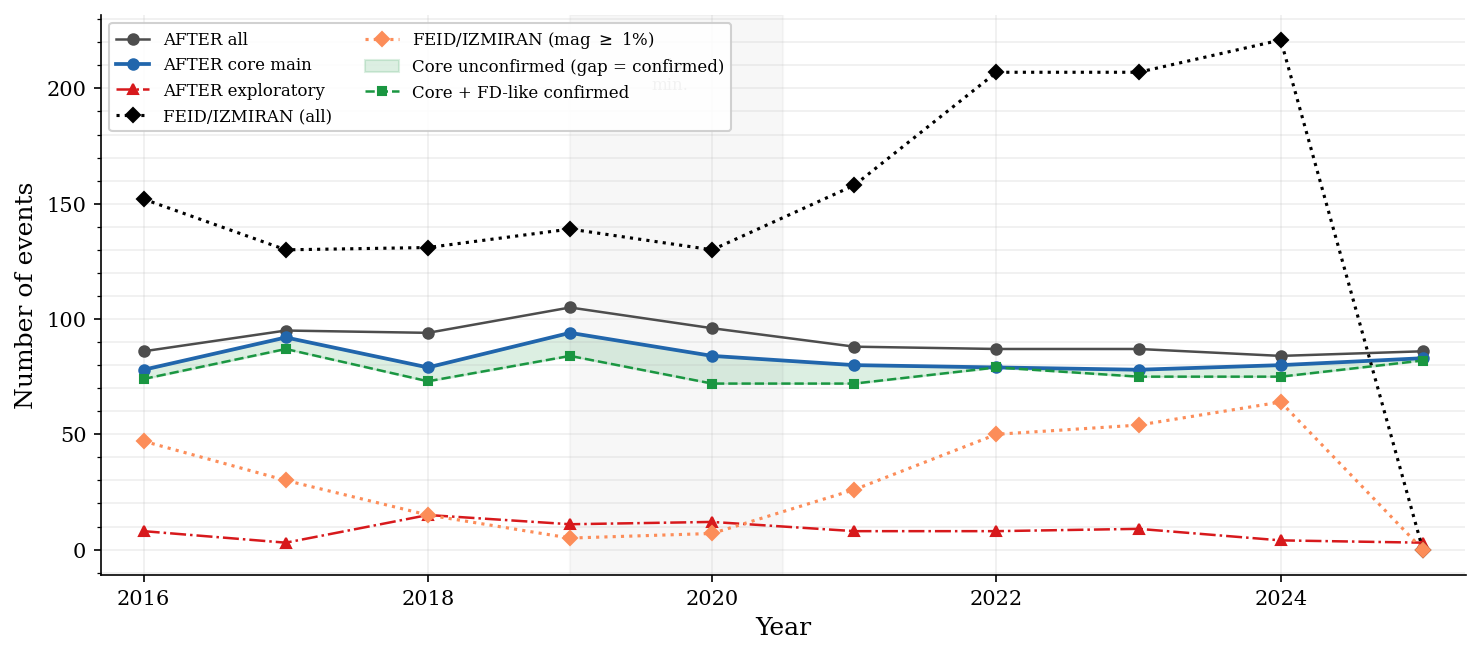

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))

# AFTER subsets
for col, label, color, ls, mk in [
    ("All",       "AFTER all",             COLORS["all"],       "-",  "o"),
    ("Core",      "AFTER core main",       COLORS["core_main"], "-",  "o"),
    ("Expl",      "AFTER exploratory",     COLORS["exploratory"],"-.","^"),
]:
    if col in t2.columns:
        ax.plot(t2.index, t2[col], color=color, ls=ls, marker=mk,
                lw=1.8 if col=="Core" else 1.2, ms=5, label=label)

# FEID reference lines
ax.plot(t2.index, t2["FEID_all"],  color=COLORS["feid_all"],
        ls=":", lw=1.5, marker="D", ms=5, label="FEID/IZMIRAN (all)")
ax.plot(t2.index, t2["FEID_1pct"], color=COLORS["feid_1pct"],
        ls=":", lw=1.5, marker="D", ms=5, label=r"FEID/IZMIRAN (mag $\geq$ 1%)")

# fd_like overlay
if has_fdlike:
    conf_yr = core_confirmed.groupby("year").size()
    ax.fill_between(conf_yr.index,
                    [t2.loc[y,"Core"] if y in t2.index else 0 for y in conf_yr.index],
                    conf_yr.values,
                    alpha=0.15, color=COLORS["confirmed"],
                    label="Core unconfirmed (gap = confirmed)")
    ax.plot(conf_yr.index, conf_yr.values,
            color=COLORS["confirmed"], ls="--", lw=1.2, marker="s", ms=4,
            label="Core + FD-like confirmed")

# Solar minimum annotation
ax.axvspan(2019, 2020.5, alpha=0.06, color="gray")
ax.text(2019.7, ax.get_ylim()[1]*0.92, "solar\nmin.",
        ha="center", va="top", fontsize=8, color="gray")

ax.set_xlabel("Year")
ax.set_ylabel("Number of events")
ax.set_xlim(t2.index.min()-0.3, t2.index.max()+0.3)
ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
ax.legend(ncol=2, framealpha=0.9, fontsize=8)
ax.grid(True, alpha=0.2, which="both")
plt.tight_layout()
savefig("fig1_annual_composition.pdf")


## Q2 — How well does AFTER recover known FD events?

Table + F1 curve only. Precision-recall at single tolerance → text.

In [5]:
def one_to_one_match(ref_times, cand_times, tol_h=18.0):
    tol   = pd.Timedelta(hours=tol_h)
    pairs = []
    for i, tr in enumerate(ref_times):
        for j, tc in enumerate(cand_times):
            if abs(tc - tr) <= tol:
                pairs.append((i, j, (tc-tr).total_seconds()/3600))
    if not pairs:
        return pd.DataFrame(columns=["ref_pos","cand_pos","dt_h"])
    pairs = sorted(pairs, key=lambda x: abs(x[2]))
    used_r, used_c, kept = set(), set(), []
    for i, j, dt in pairs:
        if i not in used_r and j not in used_c:
            used_r.add(i); used_c.add(j)
            kept.append({"ref_pos":i,"cand_pos":j,"dt_h":dt})
    return pd.DataFrame(kept)

def eval_subset(df, ref_times, tolerances=(12,18,24)):
    cand = list(pd.to_datetime(df["repr_time"]))
    rows = []
    for tol in tolerances:
        m  = one_to_one_match(ref_times, cand, tol)
        nr, nc, nm = len(ref_times), len(cand), len(m)
        rec  = nm/nr  if nr else np.nan
        prec = nm/nc  if nc else np.nan
        f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else np.nan
        rows.append({"tol_h":tol,"N_cat":nc,"N_match":nm,
                     "recall":rec,"precision":prec,"f1":f1,
                     "med_dt_h":m["dt_h"].abs().median() if not m.empty else np.nan})
    return pd.DataFrame(rows)

ref_times_2019 = list(feid_2019["t_izmiran"])
cat_2019    = cat[cat["year"]==2019].copy()
core_2019   = core[core["year"]==2019].copy()
cc_2019     = core_cons[core_cons["year"]==2019].copy()
expl_2019   = expl[expl["year"]==2019].copy()

val = pd.concat({
    "All":              eval_subset(cat_2019,  ref_times_2019),
    "Core main":        eval_subset(core_2019, ref_times_2019),
    "Core conservative":eval_subset(cc_2019,   ref_times_2019),
    "Exploratory":      eval_subset(expl_2019, ref_times_2019),
}, names=["subset"]).reset_index(level=0).reset_index(drop=True)

print("Table 4 — Validation against FEID 2019:")
display(val[["subset","tol_h","N_cat","N_match",
             "recall","precision","f1","med_dt_h"]].round(3))
val.to_csv(OUT / "table4_validation.csv", index=False)

# Inline precision-recall at 18h (no figure needed)
v18 = val[val["tol_h"]==18].set_index("subset")
print("\nPrecision-recall at ±18h (text summary):")
for s in ["All","Core main","Core conservative","Exploratory"]:
    if s in v18.index:
        r = v18.loc[s]
        print(f"  {s:25s}  recall={r['recall']:.3f}  "
              f"precision={r['precision']:.3f}  F1={r['f1']:.3f}")


Table 4 — Validation against FEID 2019:


,subset,tol_h,N_cat,N_match,recall,precision,f1,med_dt_h
0,All,12,105,39,0.281,0.371,0.320,4.450
1,All,18,105,60,0.432,0.571,0.492,9.083
2,All,24,105,72,0.518,0.686,0.590,11.267
3,Core main,12,94,36,0.259,0.383,0.309,4.533
4,Core main,18,94,55,0.396,0.585,0.472,9.167
5,Core main,24,94,66,0.475,0.702,0.567,11.267
6,Core conservative,12,84,31,0.223,0.369,0.278,4.500
7,Core conservative,18,84,49,0.353,0.583,0.439,9.167
8,Core conservative,24,84,60,0.432,0.714,0.538,11.633
9,Exploratory,12,11,3,0.022,0.273,0.040,0.567



Precision-recall at ±18h (text summary):
  All                        recall=0.432  precision=0.571  F1=0.492
  Core main                  recall=0.396  precision=0.585  F1=0.472
  Core conservative          recall=0.353  precision=0.583  F1=0.439
  Exploratory                recall=0.036  precision=0.455  F1=0.067


### Figure 2 — F1 score vs matching tolerance

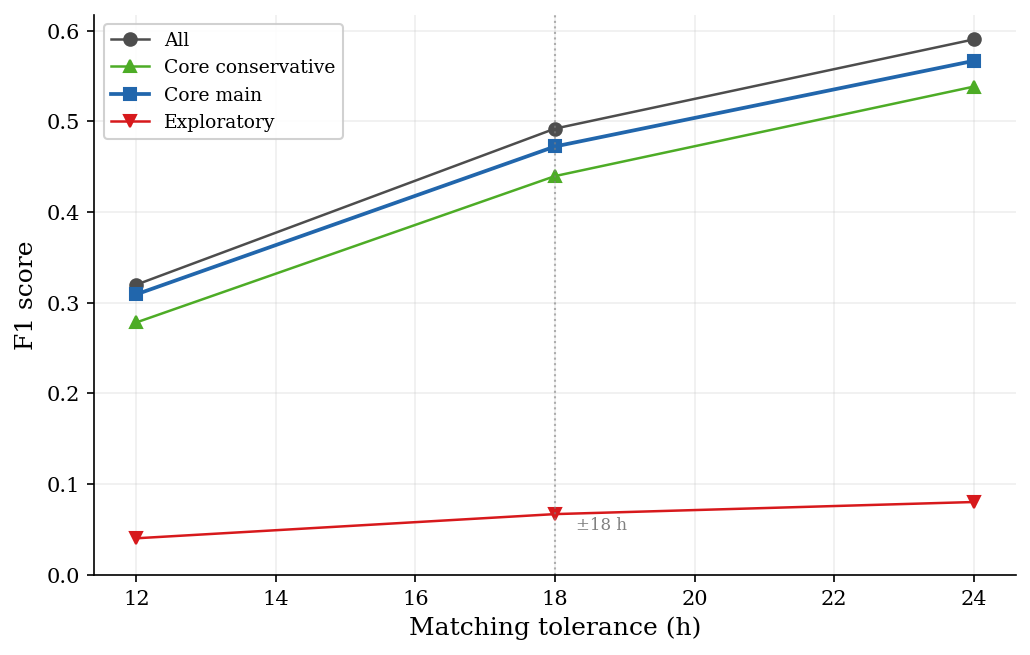

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

colors_val = {"All":COLORS["all"], "Core main":COLORS["core_main"],
              "Core conservative":COLORS["core_cons"],
              "Exploratory":COLORS["exploratory"]}
markers    = {"All":"o","Core main":"s","Core conservative":"^","Exploratory":"v"}

for subset_name, grp in val.groupby("subset"):
    ax.plot(grp["tol_h"], grp["f1"],
            marker=markers.get(subset_name,"o"),
            color=colors_val.get(subset_name,"gray"),
            lw=1.8 if "Core main" in subset_name else 1.2,
            label=subset_name)

ax.axvline(18, color="gray", ls=":", lw=1, alpha=0.6)
ax.text(18.3, 0.05, "±18 h", fontsize=8, color="gray")
ax.set_xlabel("Matching tolerance (h)")
ax.set_ylabel("F1 score")
ax.set_ylim(0, None)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
savefig("fig2_f1_validation.pdf")


## Q3 — Does the detected population have a real heliospheric signature?

Two figures: (A) FD-like confirmation by year with condition breakdown; (B) OMNI distributions confirmed vs unconfirmed.

In [7]:
if not has_fdlike:
    print("fd_like_confirmed not available — run AFTER_detector.py first")
else:
    # ── Table 5: FD-like confirmation summary ────────────────────────────────
    t5 = cat.groupby("year").agg(
        N=("fd_like_confirmed","count"),
        N_conf=("fd_like_confirmed","sum"),
        pct_A=("cond_A_bz","mean"),
        pct_B=("cond_B_speed","mean"),
        pct_C=("cond_C_imf","mean"),
    ).round(3)
    t5["pct_conf"] = (t5["N_conf"]/t5["N"]*100).round(1)
    print("Table 5 — FD-like confirmation by year:")
    display(t5[["N","N_conf","pct_conf","pct_A","pct_B","pct_C"]])
    t5.to_csv(OUT / "table5_fdlike_confirmation.csv")

    # ── Table 6: OMNI confirmed vs unconfirmed ───────────────────────────────
    omni_summary = []
    for name, df in [("Confirmed",   core_confirmed),
                     ("Unconfirmed", core_unconfirmed)]:
        for col, label in [("omni_Bz_min","Bz_min"),
                           ("omni_Speed_max","Speed_max"),
                           ("omni_IMF_max","IMF_max")]:
            if col in df.columns:
                omni_summary.append({
                    "group":  name,
                    "var":    label,
                    "mean":   df[col].mean(),
                    "median": df[col].median(),
                    "std":    df[col].std(),
                })
    t6 = pd.DataFrame(omni_summary).round(2)
    print("\nTable 6 — OMNI context confirmed vs unconfirmed:")
    display(t6)
    t6.to_csv(OUT / "table6_omni_context.csv", index=False)


Table 5 — FD-like confirmation by year:


,N,N_conf,pct_conf,pct_A,pct_B,pct_C
year,,,,,,
2016,86,82,95.3,0.372,0.919,0.384
2017,95,89,93.7,0.263,0.926,0.400
2018,94,88,93.6,0.213,0.926,0.234
2019,105,95,90.5,0.238,0.905,0.190
2020,96,84,87.5,0.260,0.854,0.156
2021,88,80,90.9,0.352,0.864,0.398
2022,87,87,100.0,0.322,1.000,0.414
2023,87,84,96.6,0.425,0.954,0.391
2024,84,79,94.0,0.452,0.929,0.536



Table 6 — OMNI context confirmed vs unconfirmed:


,group,var,mean,median,std
0,Confirmed,Bz_min,-6.90,-5.95,4.09
1,Confirmed,Speed_max,532.49,524.31,109.60
2,Confirmed,IMF_max,11.90,10.56,5.59
3,Unconfirmed,Bz_min,-5.00,-4.75,2.11
4,Unconfirmed,Speed_max,448.77,432.25,81.40
5,Unconfirmed,IMF_max,9.91,8.60,3.87


### Figure 3 — FD-like confirmation by year and condition

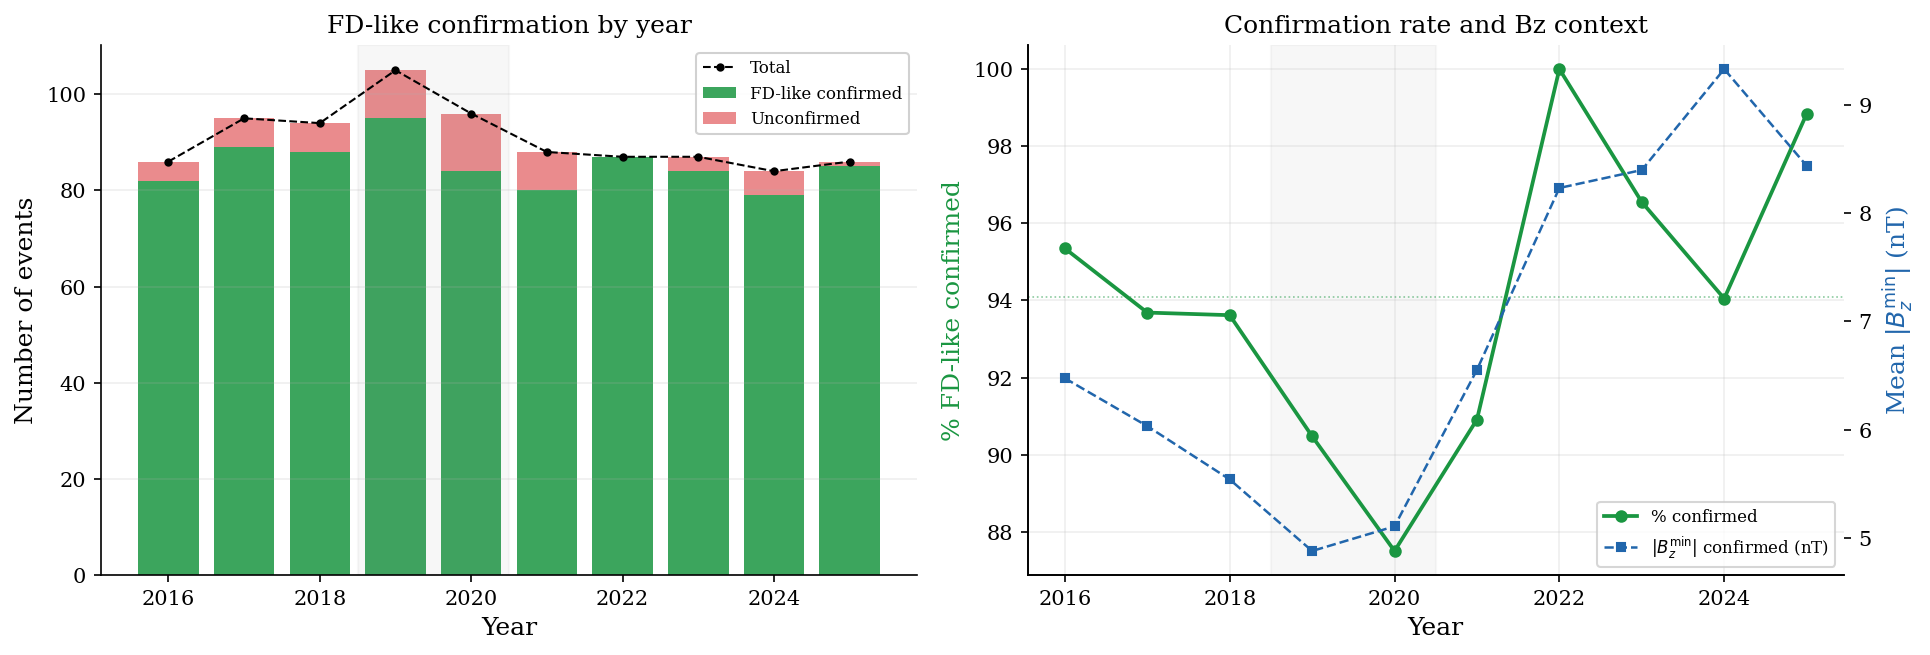

In [8]:
if has_fdlike:
    yr  = t5.copy()
    x   = yr.index.astype(int)
    N   = yr["N"].values

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Left: stacked bar of conditions A/B/C and unconfirmed
    # Each condition as fraction of N
    pA = yr["pct_A"].values * N / 100
    pB = yr["pct_B"].values * N / 100
    pC = yr["pct_C"].values * N / 100
    # Confirmed = any(A,B,C) — approximate with N_conf
    n_unc = N - yr["N_conf"].values

    axes[0].bar(x, yr["N_conf"].values,
                color=COLORS["confirmed"], alpha=0.85, label="FD-like confirmed")
    axes[0].bar(x, n_unc, bottom=yr["N_conf"].values,
                color=COLORS["unconfirmed"], alpha=0.5, label="Unconfirmed")
    axes[0].plot(x, N, color="black", ls="--", lw=1, marker="o", ms=3,
                 label="Total")

    # Solar min shading
    axes[0].axvspan(2018.5, 2020.5, alpha=0.06, color="gray")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Number of events")
    axes[0].set_title("FD-like confirmation by year")
    axes[0].legend(fontsize=8, framealpha=0.9)
    axes[0].grid(True, axis="y", alpha=0.2)

    # Right: pct confirmed + Bz mean by year
    ax2  = axes[1]
    ax2b = ax2.twinx()

    pct_conf = (yr["N_conf"]/yr["N"]*100).values
    ln1 = ax2.plot(x, pct_conf, color=COLORS["confirmed"],
                   marker="o", lw=1.8, ms=5, label="% confirmed")
    ax2.axhline(pct_conf.mean(), color=COLORS["confirmed"],
                ls=":", lw=0.8, alpha=0.5)

    # Mean |Bz_min| for confirmed events by year
    bz_yr = core_confirmed.groupby("year")["omni_Bz_min"].mean().abs()
    ln2 = ax2b.plot(bz_yr.index, bz_yr.values,
                    color=COLORS["cond_A"], marker="s", ls="--",
                    lw=1.2, ms=4, label=r"$|B_z^{\min}|$ confirmed (nT)")

    ax2.set_xlabel("Year")
    ax2.set_ylabel("% FD-like confirmed", color=COLORS["confirmed"])
    ax2b.set_ylabel(r"Mean $|B_z^{\min}|$ (nT)", color=COLORS["cond_A"])
    ax2.set_title("Confirmation rate and Bz context")
    ax2.axvspan(2018.5, 2020.5, alpha=0.06, color="gray")

    lines = ln1 + ln2
    ax2.legend(lines, [l.get_label() for l in lines], fontsize=8)
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    savefig("fig3_fdlike_by_year.pdf")


### Figure 4 — OMNI distributions: confirmed vs unconfirmed

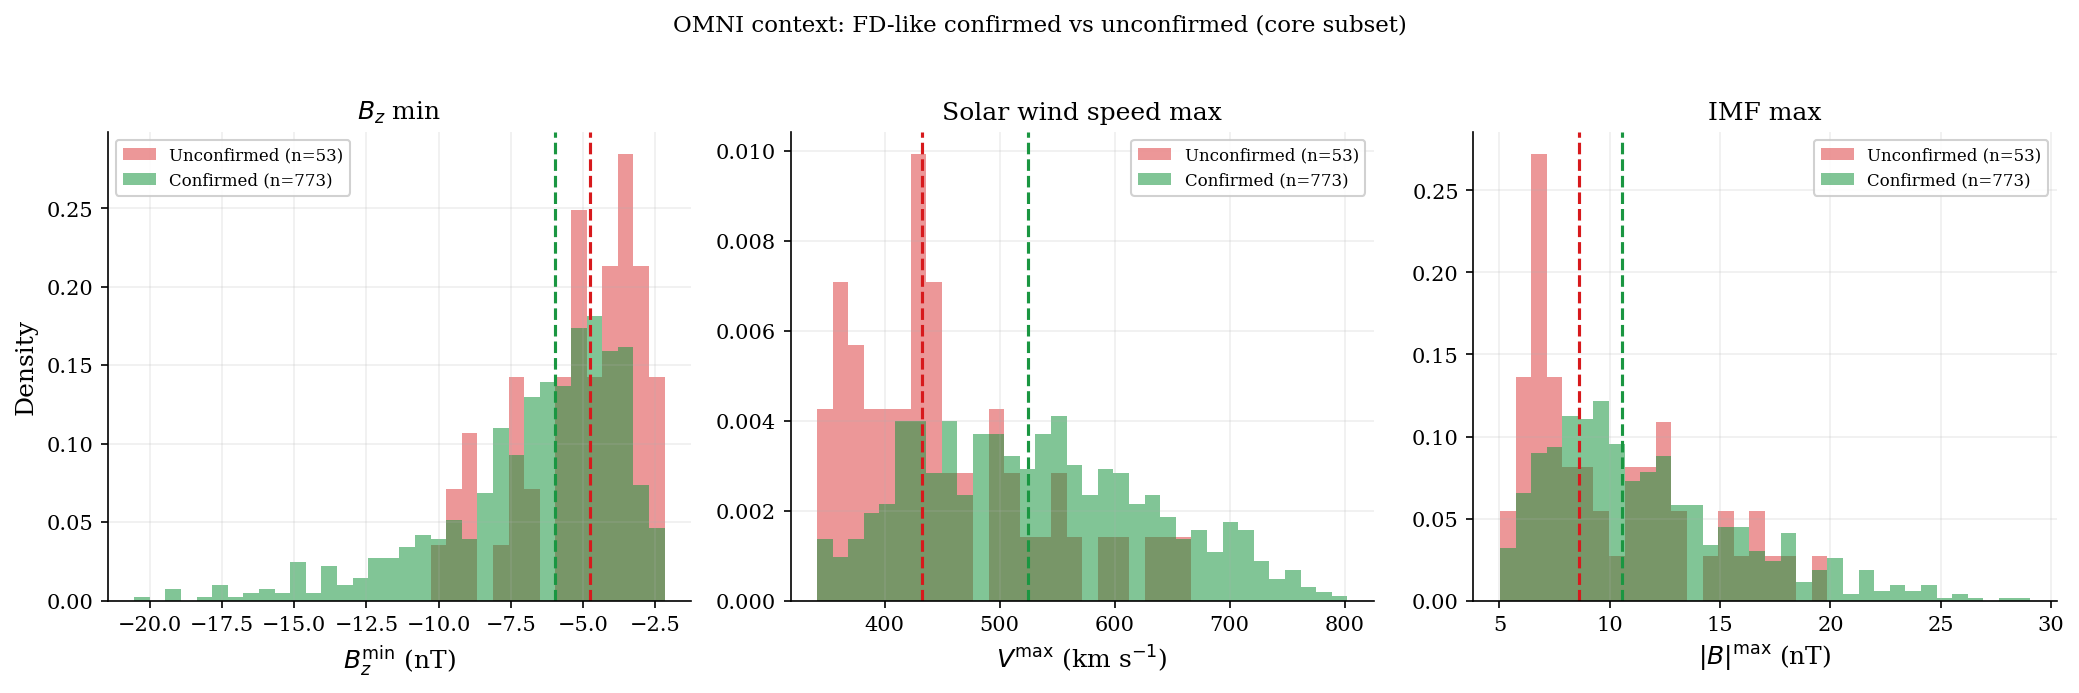

In [9]:
if has_fdlike:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    pairs = [
        ("omni_Bz_min",    r"$B_z^{\min}$ (nT)",        axes[0]),
        ("omni_Speed_max", r"$V^{\max}$ (km s$^{-1}$)",  axes[1]),
        ("omni_IMF_max",   r"$|B|^{\max}$ (nT)",         axes[2]),
    ]

    for col, xlabel, ax in pairs:
        if col not in core.columns:
            continue
        conf_vals   = core_confirmed[col].dropna()
        unconf_vals = core_unconfirmed[col].dropna()

        # Shared bins
        all_vals = pd.concat([conf_vals, unconf_vals])
        bins = np.linspace(all_vals.quantile(0.01),
                           all_vals.quantile(0.99), 35)

        ax.hist(unconf_vals, bins=bins, density=True,
                color=COLORS["unconfirmed"], alpha=0.45,
                label=f"Unconfirmed (n={len(unconf_vals):,})")
        ax.hist(conf_vals, bins=bins, density=True,
                color=COLORS["confirmed"], alpha=0.55,
                label=f"Confirmed (n={len(conf_vals):,})")

        # Median lines
        for vals, color in [(conf_vals,   COLORS["confirmed"]),
                             (unconf_vals, COLORS["unconfirmed"])]:
            ax.axvline(vals.median(), color=color, ls="--", lw=1.5)

        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density" if ax is axes[0] else "")
        ax.legend(fontsize=8, framealpha=0.9)
        ax.grid(True, alpha=0.2)

    axes[0].set_title(r"$B_z$ min")
    axes[1].set_title("Solar wind speed max")
    axes[2].set_title("IMF max")
    plt.suptitle("OMNI context: FD-like confirmed vs unconfirmed (core subset)",
                 y=1.02, fontsize=11)
    plt.tight_layout()
    savefig("fig4_omni_distributions.pdf")


## Q4 — What does AFTER miss and why?

Confusion matrix table + magnitude distribution figure.

In [10]:
# ── Build confusion matrix ────────────────────────────────────────────────────
TOL = pd.Timedelta(hours=18)

feid_matched_mask = []
for t in feid["t_izmiran"]:
    dt = (cat["repr_time"] - t).abs()
    feid_matched_mask.append(dt.min() <= TOL)

feid["after_matched"] = feid_matched_mask
feid_tp = feid[feid["after_matched"] == True].copy()
feid_fn = feid[feid["after_matched"] == False].copy()
after_fp = cat[cat["feid_matched"] == False].copy()            if "feid_matched" in cat.columns else pd.DataFrame()

print("=== Confusion matrix (±18 h) ===")
print(f"  TP (AFTER ∩ FEID):      {len(feid_tp):>6}")
print(f"  FN (FEID \ AFTER):      {len(feid_fn):>6}")
print(f"  FP (AFTER \ FEID):      {len(after_fp):>6}")
print(f"  Total FEID:             {len(feid):>6}")
print(f"  Total AFTER:            {len(cat):>6}")
print(f"\n  Recall  (TP/FEID):   {len(feid_tp)/len(feid)*100:.1f}%")
print(f"  Precision (TP/AFTER): {len(feid_tp)/len(cat)*100:.1f}%")

# ── Table 7: FN characterisation ──────────────────────────────────────────────
bins   = [0, 0.5, 1.0, 2.0, 5.0, 999]
labels = ["<0.5%","0.5–1%","1–2%","2–5%",">5%"]
feid_tp["mag_bin"] = pd.cut(feid_tp["magnitude"], bins=bins, labels=labels)
feid_fn["mag_bin"] = pd.cut(feid_fn["magnitude"], bins=bins, labels=labels)

t7 = pd.DataFrame({
    "TP": feid_tp["mag_bin"].value_counts().sort_index(),
    "FN": feid_fn["mag_bin"].value_counts().sort_index(),
}).fillna(0).astype(int)
t7["TP%"] = (t7["TP"]/t7["TP"].sum()*100).round(1)
t7["FN%"] = (t7["FN"]/t7["FN"].sum()*100).round(1)
print("\nTable 7 — TP vs FN by FEID magnitude range:")
display(t7)
t7.to_csv(OUT / "table7_tp_fn_magnitude.csv")

print(f"\nFN with mag>=1%:  {(feid_fn['magnitude']>=1.0).sum()} "
      f"({(feid_fn['magnitude']>=1.0).mean()*100:.1f}% of FN)")
print(f"FN with SSC onset: {(feid_fn[ons_col]=='SSC').sum()} "
      f"({(feid_fn[ons_col]=='SSC').mean()*100:.1f}% of FN)")


=== Confusion matrix (±18 h) ===
  TP (AFTER ∩ FEID):         622
  FN (FEID \ AFTER):         853
  FP (AFTER \ FEID):         354
  Total FEID:               1475
  Total AFTER:               908

  Recall  (TP/FEID):   42.2%
  Precision (TP/AFTER): 68.5%

Table 7 — TP vs FN by FEID magnitude range:


<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:17: SyntaxWarning: invalid escape sequence '\ '
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_56888/1560041781.py:16: SyntaxWarning: invalid escape sequence '\ '
  print(f"  FN (FEID \ AFTER):      {len(feid_fn):>6}")
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_56888/1560041781.py:17: SyntaxWarning: invalid escape sequence '\ '
  print(f"  FP (AFTER \ FEID):      {len(after_fp):>6}")


,TP,FN,TP%,FN%
mag_bin,,,,
<0.5%,213,424,34.3,49.8
0.5–1%,222,321,35.7,37.7
1–2%,136,89,21.9,10.4
2–5%,40,17,6.4,2.0
>5%,10,1,1.6,0.1



FN with mag>=1%:  111 (13.0% of FN)
FN with SSC onset: 37 (4.3% of FN)


### Figure 5 — FEID magnitude: captured vs missed events

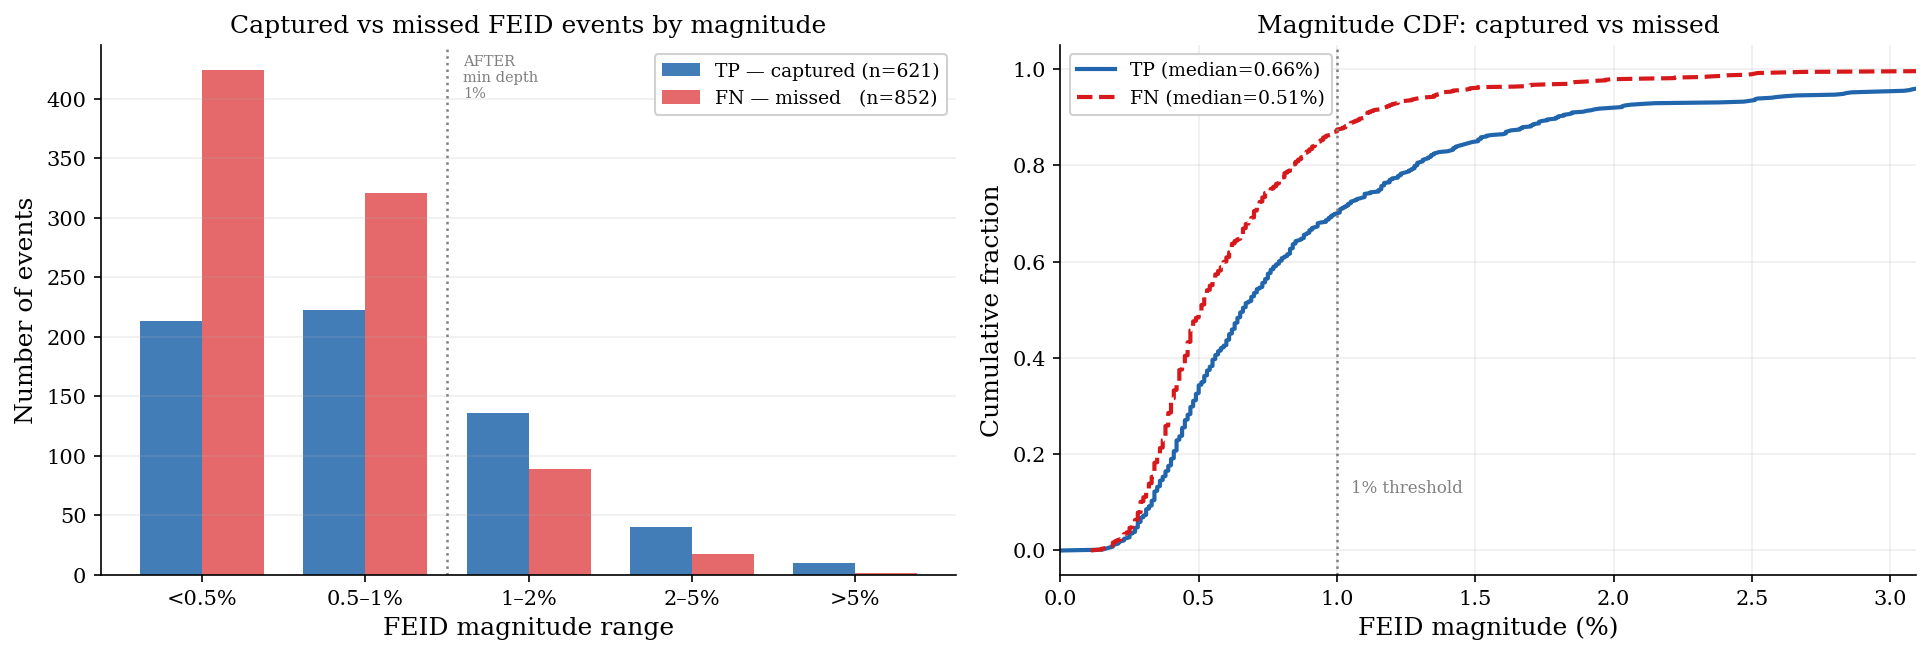

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: stacked bar by magnitude bin
x     = np.arange(len(labels))
width = 0.38
axes[0].bar(x - width/2, t7["TP"], width, color=COLORS["tp"],
            alpha=0.85, label=f"TP — captured (n={t7['TP'].sum()})")
axes[0].bar(x + width/2, t7["FN"], width, color=COLORS["fn"],
            alpha=0.65, label=f"FN — missed   (n={t7['FN'].sum()})")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_xlabel("FEID magnitude range")
axes[0].set_ylabel("Number of events")
axes[0].set_title("Captured vs missed FEID events by magnitude")
axes[0].legend(framealpha=0.9)
axes[0].grid(True, axis="y", alpha=0.2)
# Annotate design threshold
axes[0].axvline(1.5, color="gray", ls=":", lw=1.2)
axes[0].text(1.6, axes[0].get_ylim()[1]*0.9, "AFTER\nmin depth\n1%",
             fontsize=7, color="gray", ha="left")

# Right: magnitude CDF — TP vs FN
tp_mag = feid_tp["magnitude"].dropna().sort_values()
fn_mag = feid_fn["magnitude"].dropna().sort_values()

axes[1].plot(tp_mag, np.linspace(0,1,len(tp_mag)),
             color=COLORS["tp"], lw=2,
             label=f"TP (median={tp_mag.median():.2f}%)")
axes[1].plot(fn_mag, np.linspace(0,1,len(fn_mag)),
             color=COLORS["fn"], lw=2, ls="--",
             label=f"FN (median={fn_mag.median():.2f}%)")
axes[1].axvline(1.0, color="gray", ls=":", lw=1.2)
axes[1].text(1.05, 0.12, "1% threshold", fontsize=8, color="gray")
axes[1].set_xlabel("FEID magnitude (%)")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Magnitude CDF: captured vs missed")
axes[1].legend(framealpha=0.9)
axes[1].set_xlim(0, feid["magnitude"].quantile(0.98))
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
savefig("fig5_tp_fn_magnitude.pdf")


## Case studies — four representative events

**Pair 1:** FEID-matched events (different years, different support config)
**Pair 2:** AFTER-only events (one FD-like confirmed, one unconfirmed)

Each case: 3 panels — ΔN(t) per station | A_complex per station | OMNI Bz+Speed

In [12]:
# ── Select four representative cases automatically ────────────────────────────

# Build one-to-one match at ±18h for the full catalogue
m18 = one_to_one_match(list(feid["t_izmiran"]),
                       list(pd.to_datetime(cat["repr_time"])), tol_h=18.0)

matched_cat_idx   = set(m18["cand_pos"].tolist()) if not m18.empty else set()
unmatched_cat_idx = set(range(len(cat))) - matched_cat_idx

# Case 1: best FEID-matched class-A event with strong Bz (max solar activity)
#         different from 2019 — prefer 2022-2024
case1_pool = cat.iloc[sorted(matched_cat_idx)].copy()
case1_pool = case1_pool[(case1_pool["quality"]=="A") & (case1_pool["year"]>=2021)]
if "omni_Bz_min" in case1_pool.columns:
    case1_pool = case1_pool.sort_values("omni_Bz_min")  # most negative Bz first
case1 = case1_pool.iloc[0] if len(case1_pool)>0 else cat.iloc[0]

# Case 2: FEID-matched class-B promoted event from solar minimum (2019-2020)
case2_pool = cat.iloc[sorted(matched_cat_idx)].copy()
case2_pool = case2_pool[
    (case2_pool["quality"]=="B") &
    (case2_pool["year"].isin([2019,2020])) &
    (case2_pool["promoted_from_single_trigger"]==True)
] if "promoted_from_single_trigger" in case2_pool.columns else pd.DataFrame()
if len(case2_pool)==0:
    case2_pool = cat.iloc[sorted(matched_cat_idx)].copy()
    case2_pool = case2_pool[(case2_pool["quality"]=="B") &
                             (case2_pool["year"].isin([2019,2020]))]
case2 = case2_pool.iloc[0] if len(case2_pool)>0 else cat.iloc[1]

# Case 3: AFTER-only + fd_like_confirmed=True (core, strongest Bz)
if has_fdlike:
    case3_pool = cat.iloc[sorted(unmatched_cat_idx)].copy()
    case3_pool = case3_pool[
        (case3_pool["n_supported_stations"]>=2) &
        (case3_pool["fd_like_confirmed"]==True)
    ]
    if "omni_Bz_min" in case3_pool.columns:
        case3_pool = case3_pool.sort_values("omni_Bz_min")
    case3 = case3_pool.iloc[0] if len(case3_pool)>0 else cat.iloc[2]
else:
    case3 = cat.iloc[2]

# Case 4: AFTER-only + fd_like_confirmed=False (core, class-A)
if has_fdlike:
    case4_pool = cat.iloc[sorted(unmatched_cat_idx)].copy()
    case4_pool = case4_pool[
        (case4_pool["n_supported_stations"]>=2) &
        (case4_pool["fd_like_confirmed"]==False) &
        (case4_pool["quality"]=="A")
    ]
    case4 = case4_pool.iloc[0] if len(case4_pool)>0 else cat.iloc[3]
else:
    case4 = cat.iloc[3]

CASES = [
    (case1, "FEID-matched, class A, active sun"),
    (case2, "FEID-matched, class B promoted, solar minimum"),
    (case3, "AFTER-only, FD-like confirmed"),
    (case4, "AFTER-only, FD-like unconfirmed"),
]

print("Selected cases:")
for ev, label in CASES:
    t0 = pd.Timestamp(ev["repr_time"])
    q  = ev.get("quality","?")
    ns = ev.get("n_supported_stations","?")
    bz = ev.get("omni_Bz_min", np.nan)
    fd = ev.get("fd_like_confirmed","?") if has_fdlike else "?"
    print(f"  [{label}]")
    print(f"    time={t0.strftime('%Y-%m-%d %H:%M')}  Q={q}  "
          f"nsup={ns}  Bz_min={bz:.1f} nT  confirmed={fd}")


Selected cases:
  [FEID-matched, class A, active sun]
    time=2024-05-10 18:41  Q=A  nsup=15  Bz_min=-47.0 nT  confirmed=True
  [FEID-matched, class B promoted, solar minimum]
    time=2019-02-11 16:10  Q=B  nsup=3  Bz_min=-5.5 nT  confirmed=True
  [AFTER-only, FD-like confirmed]
    time=2025-11-11 14:38  Q=A  nsup=5  Bz_min=-26.4 nT  confirmed=True
  [AFTER-only, FD-like unconfirmed]
    time=2016-07-27 01:08  Q=A  nsup=6  Bz_min=-6.6 nT  confirmed=False


### Case study figures (3 panels each)

Generating case study figures...

Case 1: FEID-matched, class A, active sun


/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_56888/1874258044.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


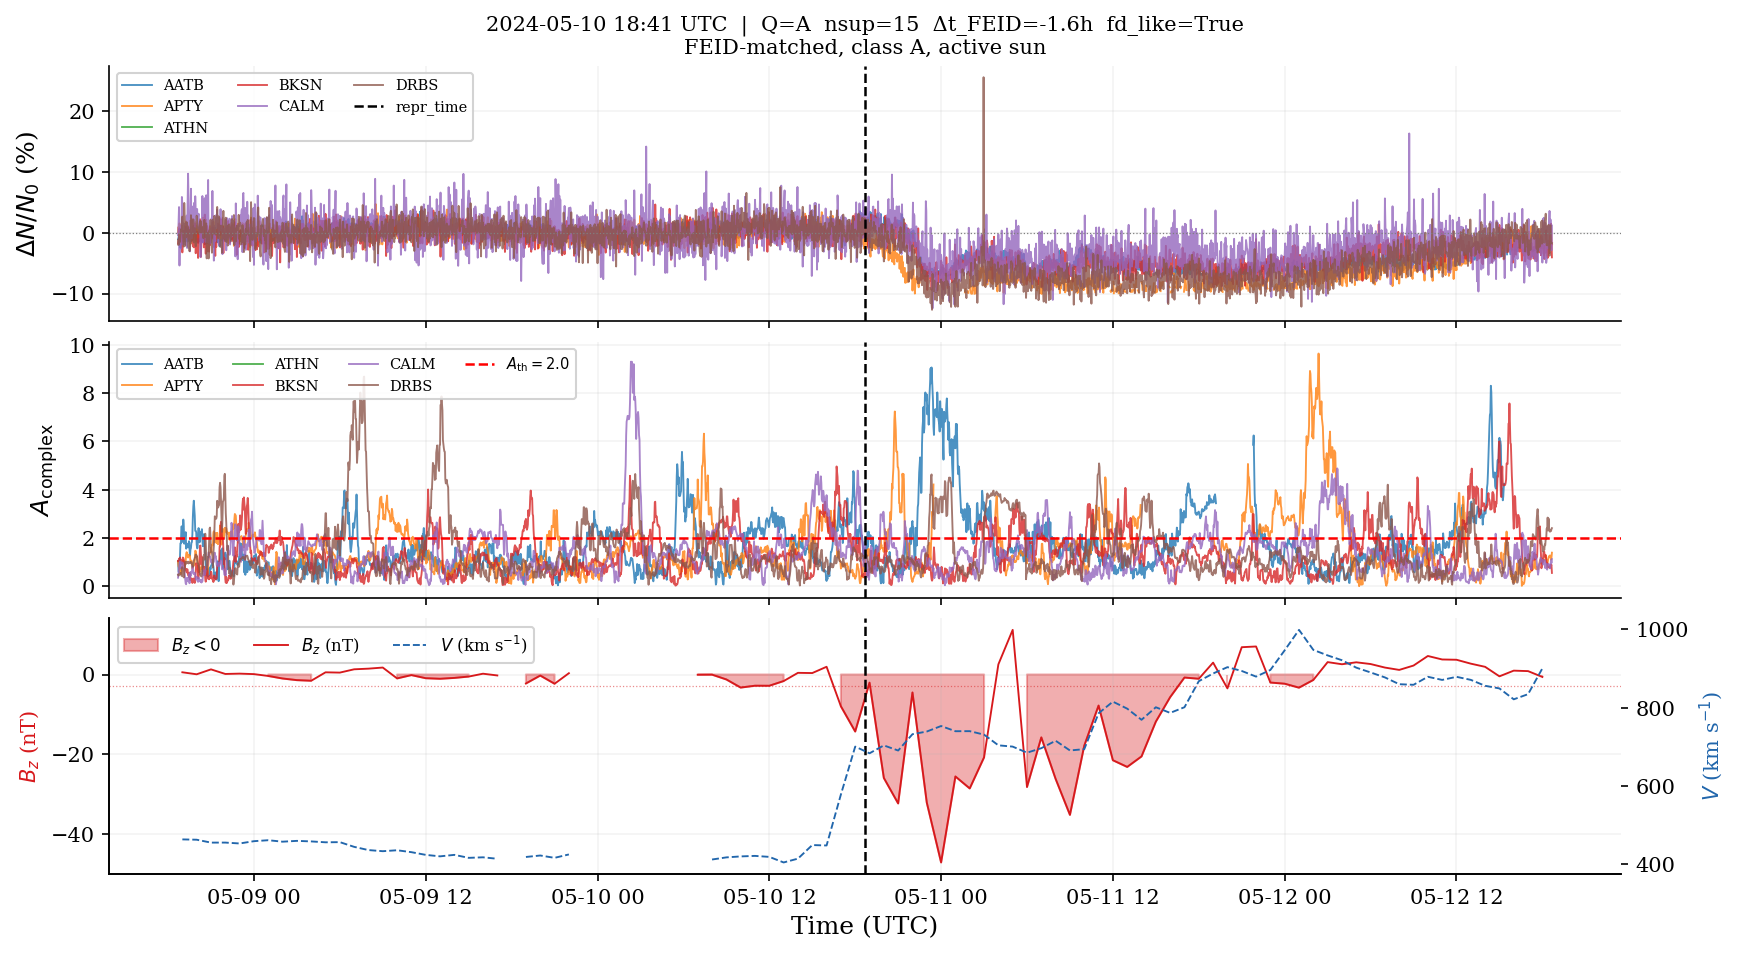

  ✓ fig_case_1_20240510_1841.pdf
Case 2: FEID-matched, class B promoted, solar minimum


/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_56888/1874258044.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


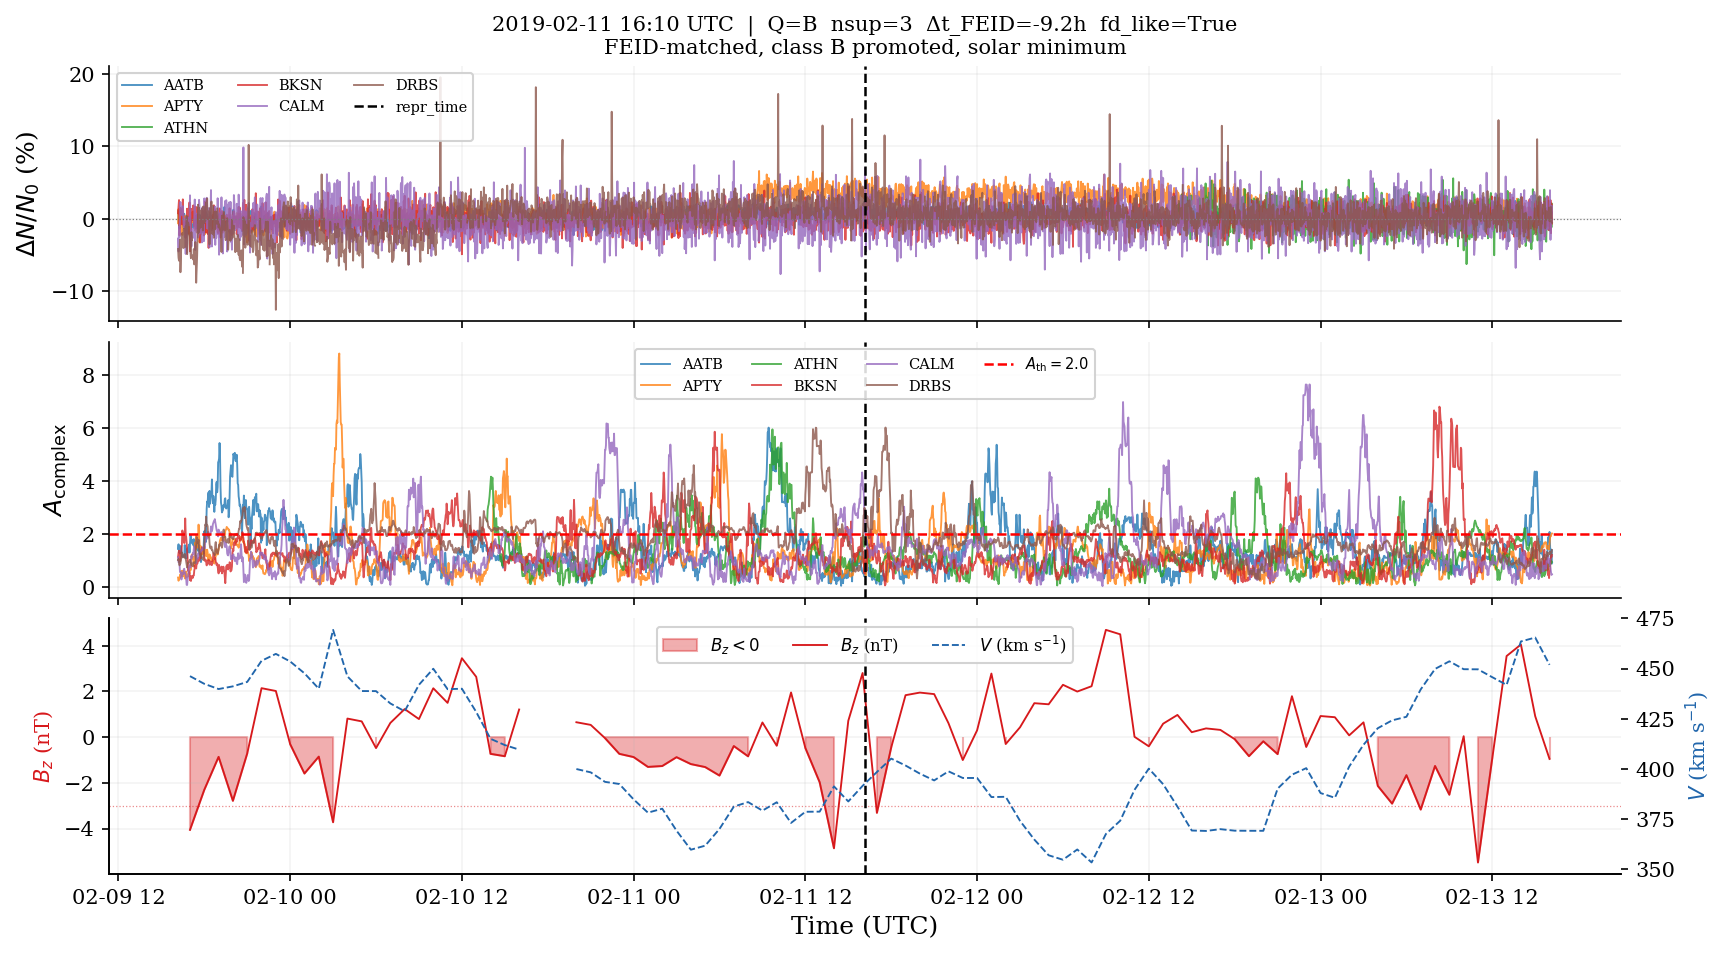

  ✓ fig_case_2_20190211_1610.pdf
Case 3: AFTER-only, FD-like confirmed


/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_56888/1874258044.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


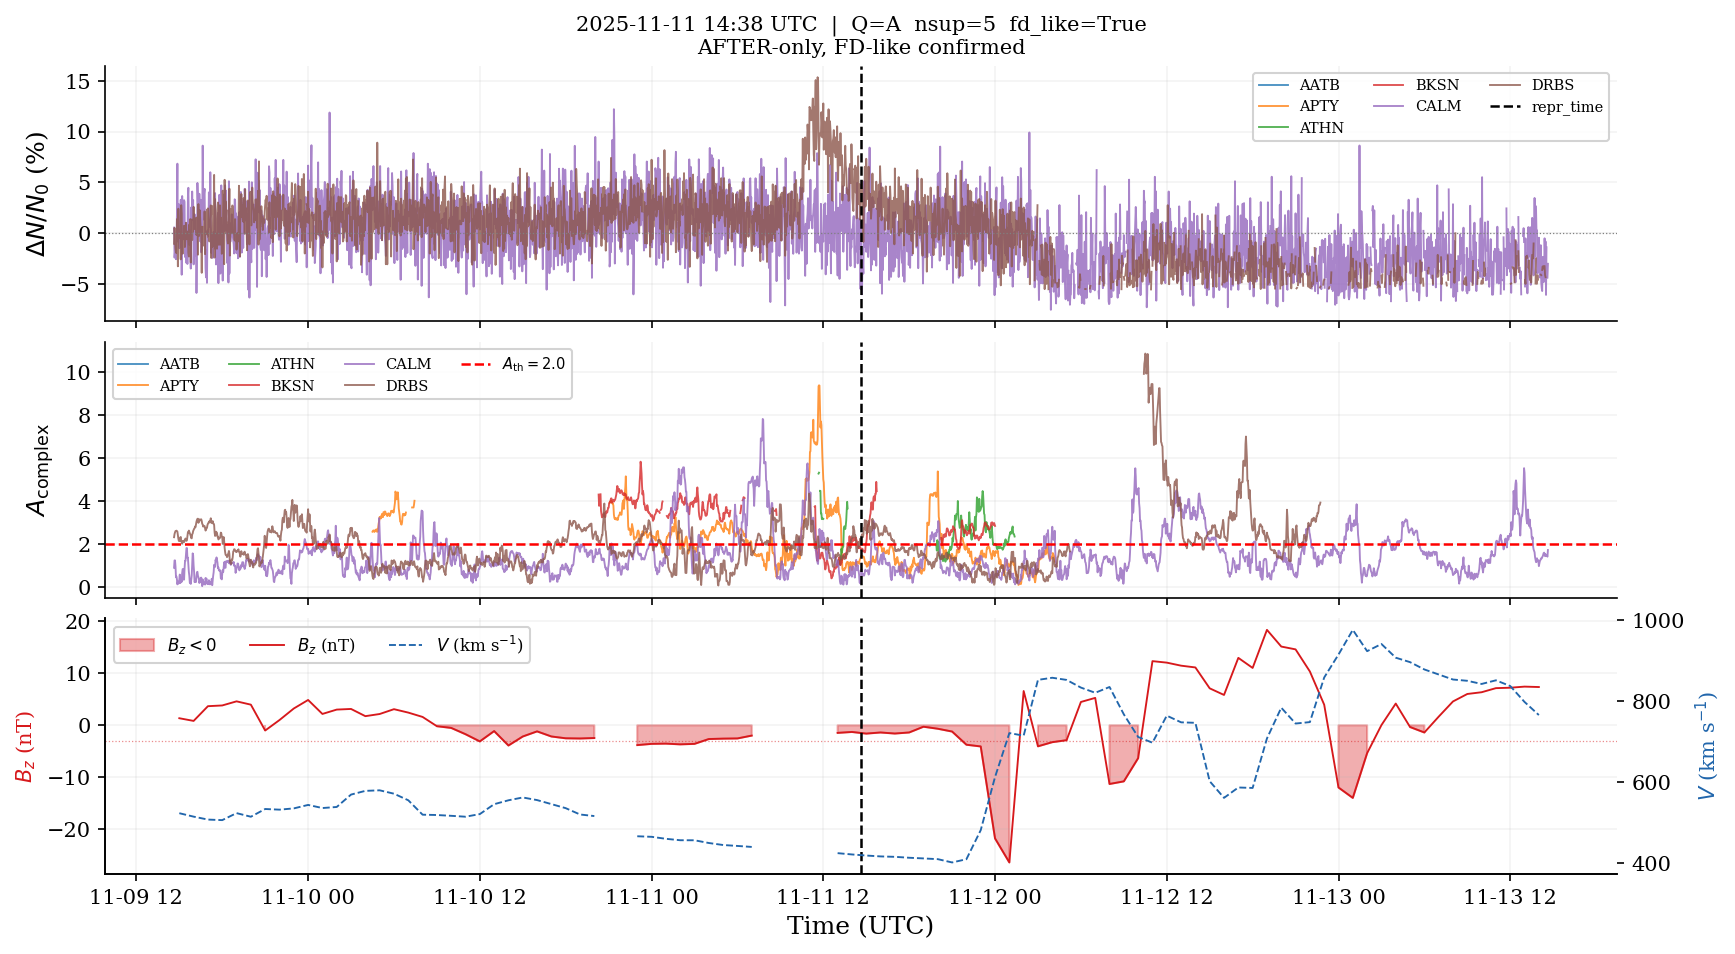

  ✓ fig_case_3_20251111_1438.pdf
Case 4: AFTER-only, FD-like unconfirmed


/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_56888/1874258044.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


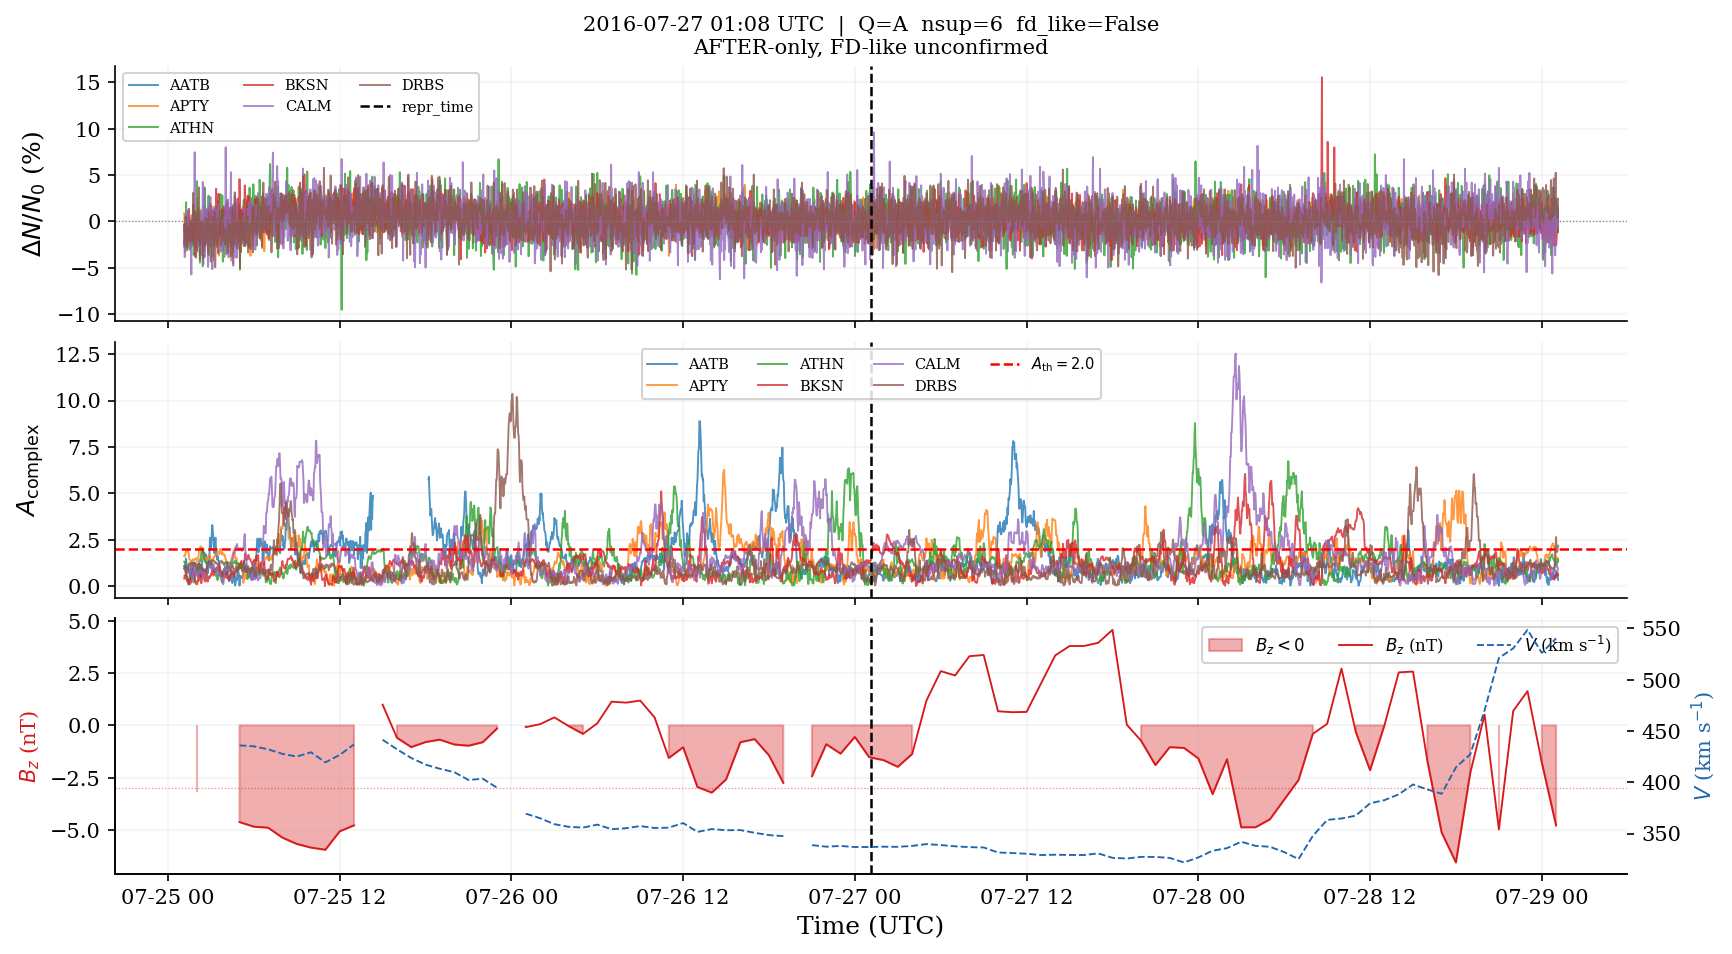

  ✓ fig_case_4_20160727_0108.pdf


In [13]:
def plot_case(ev, label, figname, omni_df, n_stations=6):
    """
    Three-panel case study:
      Top:    ΔN relative deviation per station
      Middle: A_complex per station with Ath line
      Bottom: OMNI Bz (red fill) and Speed (blue dashed)
    """
    t0    = pd.Timestamp(ev["repr_time"])
    if t0.tzinfo is not None:
        t0 = t0.tz_convert(None)
    t_pre = t0 - pd.Timedelta(hours=48)
    t_pos = t0 + pd.Timedelta(hours=48)

    # Choose stations: prefer supporting stations if available
    st_list = STATIONS_AVAILABLE[:n_stations]

    # Load panels and extract window
    panels_win = {}
    for st in st_list:
        try:
            p = load_panel(st)
            w = p.loc[t_pre:t_pos]
            if not w.empty and "deltaN" in w.columns:
                panels_win[st] = w
        except Exception:
            pass
    if not panels_win:
        print(f"  No panel data for {label}")
        return

    fig = plt.figure(figsize=(13, 7))
    gs  = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1],
                             hspace=0.08)
    ax0 = fig.add_subplot(gs[0])   # deltaN
    ax1 = fig.add_subplot(gs[1], sharex=ax0)   # A_complex
    ax2 = fig.add_subplot(gs[2], sharex=ax0)   # OMNI

    cmap   = plt.cm.tab10
    st_colors = {st: cmap(i/10) for i,st in enumerate(panels_win.keys())}

    # ── Panel 1: ΔN ──────────────────────────────────────────────────────────
    for st, w in panels_win.items():
        ax0.plot(w.index, w["deltaN"],
                 color=st_colors[st], lw=0.9, alpha=0.8, label=st)
    ax0.axhline(0, color="gray", lw=0.6, ls=":")
    ax0.axvline(t0, color="black", lw=1.2, ls="--", label="repr_time")
    ax0.set_ylabel(r"$\Delta N / N_0$ (%)")
    ax0.legend(ncol=3, fontsize=7, framealpha=0.85)
    ax0.grid(True, alpha=0.15)

    # Event metadata in title
    q   = ev.get("quality","?")
    ns  = ev.get("n_supported_stations","?")
    fd  = f"  fd_like={ev.get('fd_like_confirmed','?')}" if has_fdlike else ""
    fdt = f"  Δt_FEID={ev.get('feid_dt_h',np.nan):.1f}h"           if "feid_dt_h" in ev.index and not pd.isna(ev.get("feid_dt_h")) else ""
    ax0.set_title(
        f"{t0.strftime('%Y-%m-%d %H:%M UTC')}  |  "
        f"Q={q}  nsup={ns}{fdt}{fd}\n{label}",
        fontsize=10)

    # ── Panel 2: A_complex ───────────────────────────────────────────────────
    for st, w in panels_win.items():
        if "A_complex" in w.columns:
            ax1.plot(w.index, w["A_complex"],
                     color=st_colors[st], lw=0.9, alpha=0.8, label=st)
    ax1.axhline(ATH, color="red", lw=1.2, ls="--",
                label=f"$A_{{\\mathrm{{th}}}}={ATH}$")
    ax1.axvline(t0, color="black", lw=1.2, ls="--")
    ax1.set_ylabel(r"$A_{\mathrm{complex}}$")
    ax1.legend(ncol=4, fontsize=7, framealpha=0.85)
    ax1.grid(True, alpha=0.15)

    # ── Panel 3: OMNI ────────────────────────────────────────────────────────
    win_omni = omni_df.loc[t_pre:t_pos]
    ax2b = ax2.twinx()

    if "BZ" in win_omni.columns:
        bz = win_omni["BZ"].fillna(0)
        ax2.fill_between(win_omni.index, bz, 0,
                          where=bz<0, color="#d7191c", alpha=0.35,
                          label=r"$B_z < 0$")
        ax2.plot(win_omni.index, win_omni["BZ"],
                  color="#d7191c", lw=0.9, label=r"$B_z$ (nT)")
        ax2.axhline(-3, color="#d7191c", lw=0.6, ls=":", alpha=0.5)

    if "Speed" in win_omni.columns:
        ax2b.plot(win_omni.index, win_omni["Speed"],
                   color="#2166ac", lw=0.9, ls="--",
                   label=r"$V$ (km s$^{-1}$)")
        ax2b.set_ylabel(r"$V$ (km s$^{-1}$)", color="#2166ac", fontsize=10)

    ax2.axvline(t0, color="black", lw=1.2, ls="--")
    ax2.set_ylabel(r"$B_z$ (nT)", color="#d7191c", fontsize=10)
    ax2.set_xlabel("Time (UTC)")
    ax2.grid(True, alpha=0.15)

    # Combined legend
    h1, l1 = ax2.get_legend_handles_labels()
    h2, l2 = ax2b.get_legend_handles_labels()
    ax2.legend(h1+h2, l1+l2, fontsize=8, framealpha=0.85, ncol=3)

    # Remove x-tick labels on top panels
    plt.setp(ax0.get_xticklabels(), visible=False)
    plt.setp(ax1.get_xticklabels(), visible=False)

    plt.tight_layout()
    savefig(figname)
    print(f"  ✓ {figname}")


# ── Generate four case study figures ──────────────────────────────────────────
print("Generating case study figures...\n")
for i, (ev, label) in enumerate(CASES, start=1):
    t0 = pd.Timestamp(ev["repr_time"])
    if t0.tzinfo is not None:
        t0 = t0.tz_convert(None)
    fname = f"fig_case_{i}_{t0.strftime('%Y%m%d_%H%M')}.pdf"
    print(f"Case {i}: {label}")
    plot_case(ev, label, fname, omni_1h)


## Key numbers for the paper

In [14]:
v18_all  = val[val["tol_h"]==18].query("subset=='All'").iloc[0]
v18_core = val[val["tol_h"]==18].query("subset=='Core main'").iloc[0]

key = {
    "n_total":              len(cat),
    "n_core_main":          len(core),
    "n_core_conservative":  len(core_cons),
    "n_exploratory":        len(expl),
    "n_promoted":           int(cat["promoted_from_single_trigger"].sum())
                            if "promoted_from_single_trigger" in cat.columns else "?",
    "pct_promoted":         round(cat["promoted_from_single_trigger"].mean()*100, 1)
                            if "promoted_from_single_trigger" in cat.columns else "?",
    "mean_nsup_all":        round(cat["n_supported_stations"].mean(), 2),
    "mean_nsup_core":       round(core["n_supported_stations"].mean(), 2),
    "all_18h_recall":       round(v18_all["recall"], 3),
    "all_18h_precision":    round(v18_all["precision"], 3),
    "all_18h_f1":           round(v18_all["f1"], 3),
    "core_18h_recall":      round(v18_core["recall"], 3),
    "core_18h_precision":   round(v18_core["precision"], 3),
    "core_18h_f1":          round(v18_core["f1"], 3),
    "n_fdlike_confirmed":   int(cat["fd_like_confirmed"].sum()) if has_fdlike else "?",
    "pct_core_confirmed":   round(core["fd_like_confirmed"].mean()*100, 1)
                            if has_fdlike else "?",
    "tp_total":             len(feid_tp),
    "fn_total":             len(feid_fn),
    "fp_total":             len(after_fp),
    "fn_large_pct":         round((feid_fn["magnitude"]>=1.0).mean()*100, 1),
}

df_key = pd.DataFrame(list(key.items()), columns=["metric","value"])
display(df_key)
df_key.to_csv(OUT / "table_key_numbers.csv", index=False)
print(f"\nAll outputs saved to: {OUT.resolve()}")


,metric,value
0,n_total,908.000
1,n_core_main,827.000
2,n_core_conservative,764.000
3,n_exploratory,81.000
4,n_promoted,213.000
5,pct_promoted,23.500
6,mean_nsup_all,6.570
7,mean_nsup_core,7.120
8,all_18h_recall,0.432
9,all_18h_precision,0.571



All outputs saved to: /Users/neno/Documents/NMDB/SierraMethod/NEWVERSION/Results_v2_4/Analysis


Generating case study figures...

Case 1: FEID-matched, class A, active sun


/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_56888/1004081092.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


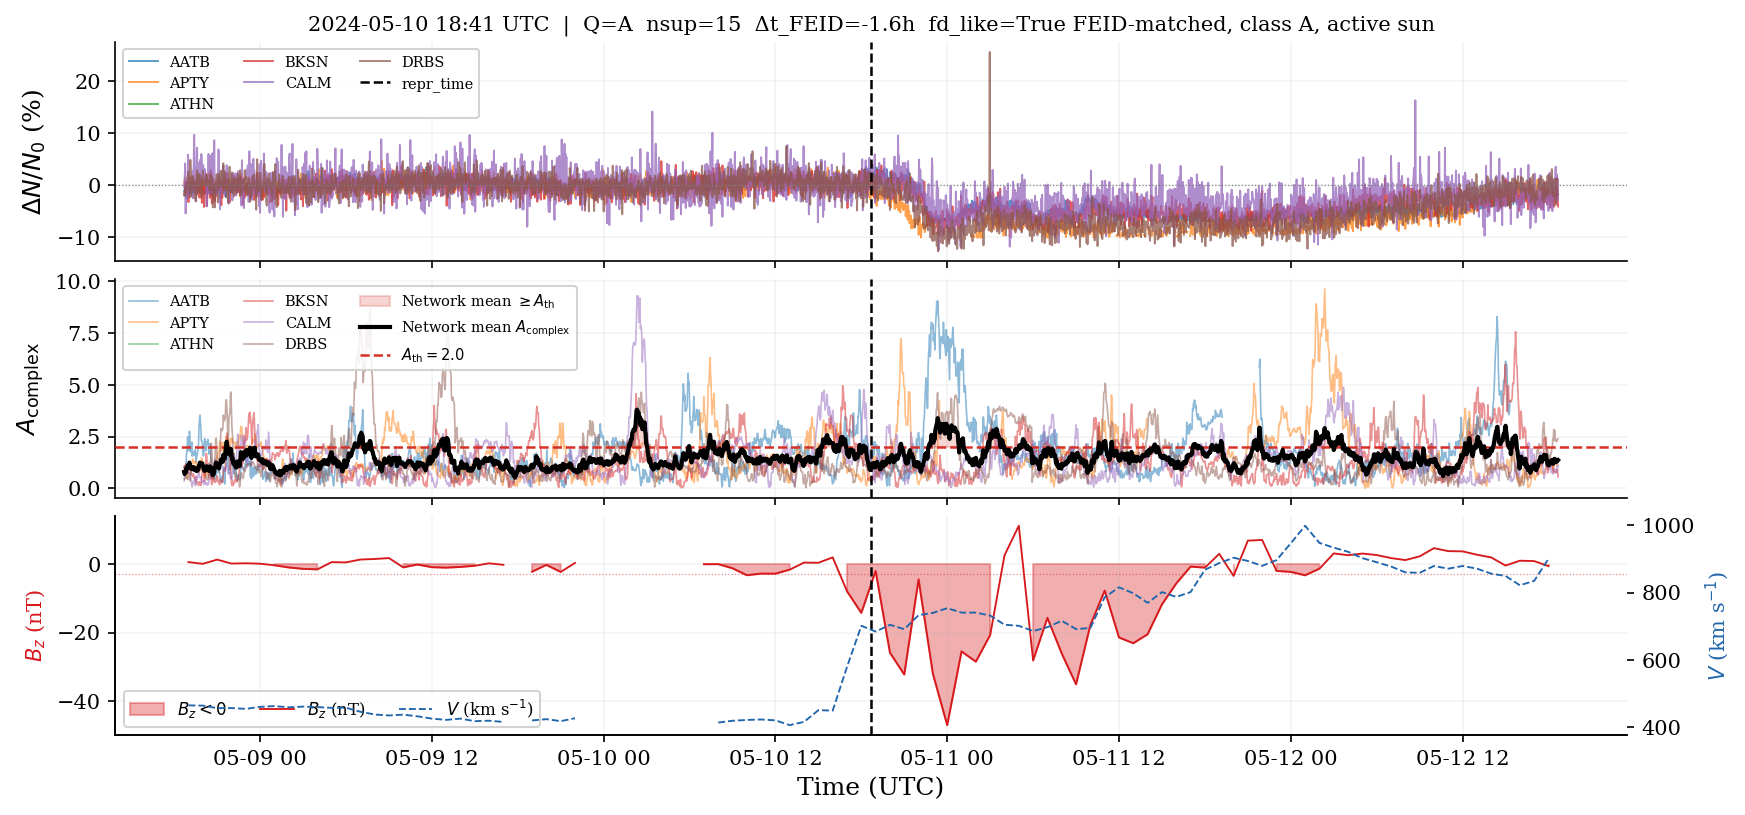

  ✓ fig_case_1_20240510_1841.pdf
Case 2: FEID-matched, class B promoted, solar minimum


/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_56888/1004081092.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


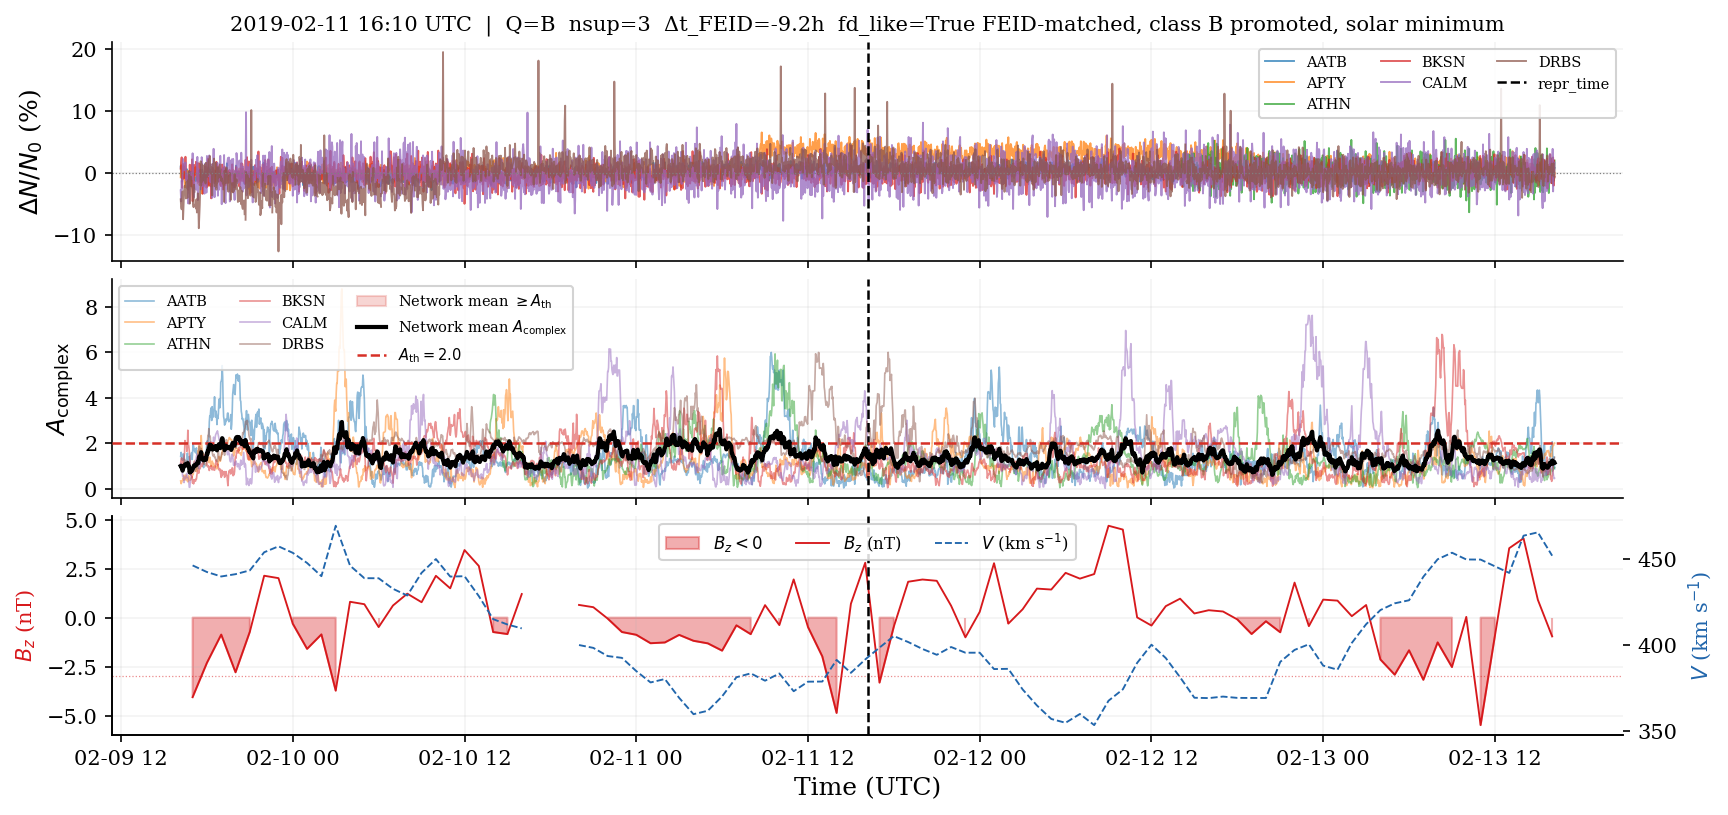

  ✓ fig_case_2_20190211_1610.pdf
Case 3: AFTER-only, FD-like confirmed


/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_56888/1004081092.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


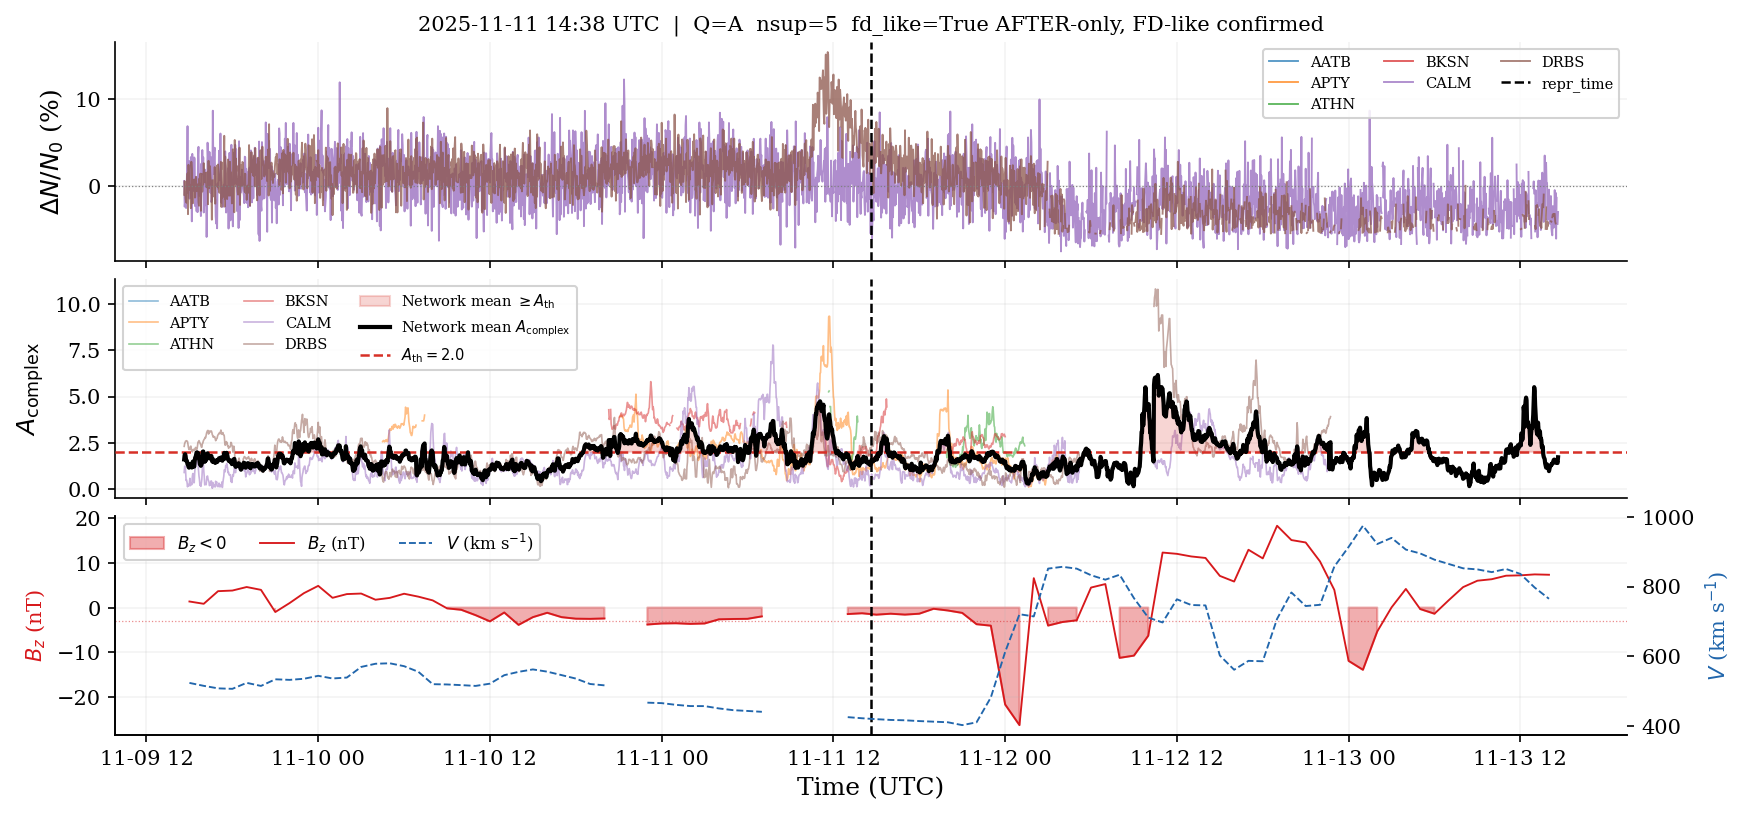

  ✓ fig_case_3_20251111_1438.pdf
Case 4: AFTER-only, FD-like unconfirmed


/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_56888/1004081092.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


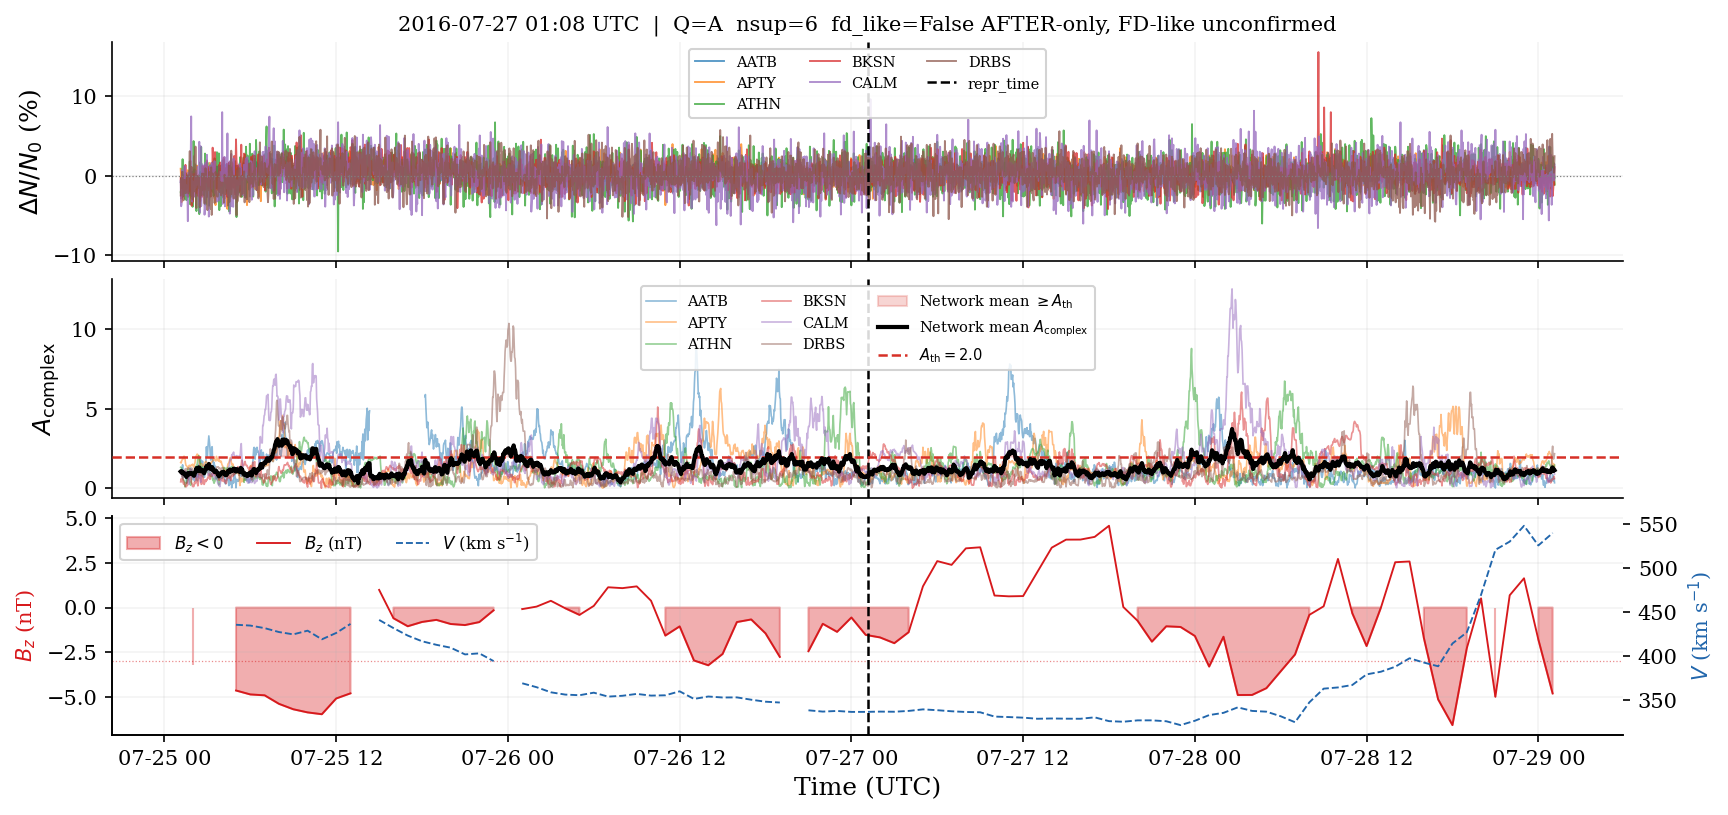

  ✓ fig_case_4_20160727_0108.pdf


In [15]:
def plot_case(ev, label, figname, omni_df, n_stations=6):
    """
    Three-panel case study:
      Top:    ΔN relative deviation per station
      Middle: A_complex per station + network mean (black bold) + shading >= Ath
      Bottom: OMNI Bz (red fill) and Speed (blue dashed)
    """
    t0    = pd.Timestamp(ev["repr_time"])
    if t0.tzinfo is not None:
        t0 = t0.tz_convert(None)
    t_pre = t0 - pd.Timedelta(hours=48)
    t_pos = t0 + pd.Timedelta(hours=48)

    # Choose stations
    st_list = STATIONS_AVAILABLE[:n_stations]

    # Load panels and extract window
    panels_win = {}
    for st in st_list:
        try:
            p = load_panel(st)
            w = p.loc[t_pre:t_pos]
            if not w.empty and "deltaN" in w.columns:
                panels_win[st] = w
        except Exception:
            pass
    if not panels_win:
        print(f"  No panel data for {label}")
        return

    fig = plt.figure(figsize=(13, 6))
    gs  = gridspec.GridSpec(3, 1, height_ratios=[2, 2, 2],
                             hspace=0.08)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax2 = fig.add_subplot(gs[2], sharex=ax0)

    cmap      = plt.cm.tab10
    st_colors = {st: cmap(i/10) for i, st in enumerate(panels_win.keys())}

    # ── Panel 1: ΔN ──────────────────────────────────────────────────────────
    for st, w in panels_win.items():
        ax0.plot(w.index, w["deltaN"],
                 color=st_colors[st], lw=0.9, alpha=0.75, label=st)
    ax0.axhline(0, color="gray", lw=0.6, ls=":")
    ax0.axvline(t0, color="black", lw=1.2, ls="--", label="repr_time")
    ax0.set_ylabel(r"$\Delta N / N_0$ (%)")
    ax0.legend(ncol=3, fontsize=7, framealpha=0.85)
    ax0.grid(True, alpha=0.15)

    # Event metadata in title
    q   = ev.get("quality", "?")
    ns  = ev.get("n_supported_stations", "?")
    fd  = f"  fd_like={ev.get('fd_like_confirmed','?')}" if has_fdlike else ""
    fdt = (f"  \u0394t_FEID={ev.get('feid_dt_h', np.nan):.1f}h"
           if "feid_dt_h" in ev.index and not pd.isna(ev.get("feid_dt_h"))
           else "")
    ax0.set_title(
        f"{t0.strftime('%Y-%m-%d %H:%M UTC')}  |  "
        f"Q={q}  nsup={ns}{fdt}{fd} {label}",
        fontsize=10)

    # ── Panel 2: A_complex individual + network mean ──────────────────────────
    # Individual station curves
    ac_series = {}
    for st, w in panels_win.items():
        if "A_complex" in w.columns:
            ax1.plot(w.index, w["A_complex"],
                     color=st_colors[st], lw=0.8, alpha=0.5, label=st)
            ac_series[st] = w["A_complex"]

    # Network mean A_complex
    if ac_series:
        ac_df   = pd.DataFrame(ac_series)
        ac_mean = ac_df.mean(axis=1)

        # Shading where network mean >= Ath
        ax1.fill_between(ac_mean.index, ATH, ac_mean.values,
                          where=ac_mean.values >= ATH,
                          alpha=0.20, color="#d73027", zorder=2,
                          label=r"Network mean $\geq A_{\mathrm{th}}$")

        # Network mean line
        ax1.plot(ac_mean.index, ac_mean.values,
                  color="black", lw=2.0, ls="-", zorder=4,
                  label=r"Network mean $A_{\mathrm{complex}}$")

    ax1.axhline(ATH, color="#d73027", lw=1.2, ls="--", zorder=3,
                label=f"$A_{{\\mathrm{{th}}}}={ATH}$")
    ax1.axvline(t0, color="black", lw=1.2, ls="--")
    ax1.set_ylabel(r"$A_{\mathrm{complex}}$")
    ax1.legend(ncol=3, fontsize=7, framealpha=0.85)
    ax1.grid(True, alpha=0.15)

    # ── Panel 3: OMNI ─────────────────────────────────────────────────────────
    win_omni = omni_df.loc[t_pre:t_pos]
    ax2b     = ax2.twinx()

    if "BZ" in win_omni.columns:
        bz = win_omni["BZ"].fillna(0)
        ax2.fill_between(win_omni.index, bz, 0,
                          where=bz < 0, color="#d7191c", alpha=0.35,
                          label=r"$B_z < 0$")
        ax2.plot(win_omni.index, win_omni["BZ"],
                  color="#d7191c", lw=0.9, label=r"$B_z$ (nT)")
        ax2.axhline(-3, color="#d7191c", lw=0.6, ls=":", alpha=0.5)

    if "Speed" in win_omni.columns:
        ax2b.plot(win_omni.index, win_omni["Speed"],
                   color="#2166ac", lw=0.9, ls="--",
                   label=r"$V$ (km s$^{-1}$)")
        ax2b.set_ylabel(r"$V$ (km s$^{-1}$)", color="#2166ac", fontsize=10)

    ax2.axvline(t0, color="black", lw=1.2, ls="--")
    ax2.set_ylabel(r"$B_z$ (nT)", color="#d7191c", fontsize=10)
    ax2.set_xlabel("Time (UTC)")
    ax2.grid(True, alpha=0.15)

    h1, l1 = ax2.get_legend_handles_labels()
    h2, l2 = ax2b.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, fontsize=8, framealpha=0.85, ncol=3)

    plt.setp(ax0.get_xticklabels(), visible=False)
    plt.setp(ax1.get_xticklabels(), visible=False)

    plt.tight_layout()
    savefig(figname)
    print(f"  ✓ {figname}")


# ── Generate four case study figures ──────────────────────────────────────────
print("Generating case study figures...\n")
for i, (ev, label) in enumerate(CASES, start=1):
    t0 = pd.Timestamp(ev["repr_time"])
    if t0.tzinfo is not None:
        t0 = t0.tz_convert(None)
    fname = f"fig_case_{i}_{t0.strftime('%Y%m%d_%H%M')}.pdf"
    print(f"Case {i}: {label}")
    plot_case(ev, label, fname, omni_1h)